# Model training for trajectory data

In [1]:
import sys
import os
sys.path.append(os.path.abspath("../.."))

from app.data_providers import test_train_dataset
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import TargetEncoder
from sklearn.preprocessing import FunctionTransformer

from sklearn.calibration import CalibrationDisplay

from sklearn.pipeline import FeatureUnion
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_transformer

from sklearn.metrics import roc_auc_score, f1_score, brier_score_loss
from sklearn.metrics import classification_report

from imblearn.over_sampling import RandomOverSampler

from xgboost import XGBClassifier

import joblib

from copy import deepcopy

import shap

pd.set_option('display.max_columns', None)

In [2]:
#data_train = pd.read_parquet(r"../../data/trajectory_tests/train_new.parquet")
#data_test = pd.read_parquet(r"../../data/trajectory_tests/test_new.parquet")

data_train = pd.read_parquet(r"../../data/trajectory_tests/train_new_20_players_v3.parquet")
data_test = pd.read_parquet(r"../../data/trajectory_tests/test_new_20_players_v3.parquet")

X_train = data_train.drop('SHOT_MADE_FLAG', axis=1)
y_train = data_train['SHOT_MADE_FLAG']

X_test = data_test.drop('SHOT_MADE_FLAG', axis=1)
y_test = data_test['SHOT_MADE_FLAG']

# Initial test

In [3]:
#feature_set_reduced = ['GAME_ID', 'GAME_EVENT_ID', 'shooter_x', 'shooter_y', 'shot_angle', 'distance_to_basket_tracking', 'nearest_defender_dist',
#    'avg_defender_dist', 'defenders_within_3ft', 'defenders_within_5ft', 'defenders_within_7ft',
#   'offensive_spacing_area', 'shooter_speed', 'defender_closing_speed',
#    'nearest_teammate_distance', 'defenders_between', 'has_screen', 'offensive_spacing', 'teammate_between_defender', 'players_in_paint']

feature_set_reduced = ['shooter_x', 'shooter_y', 'shot_angle', 'distance_to_basket_tracking', 'nearest_defender_dist',
    'avg_defender_dist', 'defenders_within_3ft', 'defenders_within_5ft', 'defenders_within_7ft',
    'shooter_speed', 'defender_closing_speed',
    'nearest_teammate_distance', 'defenders_between', 'has_screen', 'offensive_spacing', 'teammate_between_defender', 'players_in_paint']

def select_features(df_):
    return df_[feature_set_reduced]

In [4]:
X_train.head()

,Unnamed: 0,shooter_slot,shooter_x,shooter_y,shooter_team_id,shot_angle,distance_to_basket_tracking,nearest_defender_dist,avg_defender_dist,defenders_within_3ft,defenders_within_5ft,defenders_within_7ft,offensive_spacing_area,shooter_speed,player1_speed,player2_speed,player3_speed,player4_speed,player5_speed,player6_speed,player7_speed,player8_speed,player9_speed,player10_speed,defender_closing_speed,ball_height,ball_speed,ball_xy_speed,ACTION_TYPE,EVENTTIME,EVENT_TYPE,GAME_DATE,GAME_EVENT_ID,GAME_ID,GRID_TYPE,HTM,LOC_X,LOC_Y,MINUTES_REMAINING,PERIOD,PLAYER_ID,PLAYER_NAME,QUARTER,SECONDS_REMAINING,SHOT_ATTEMPTED_FLAG,SHOT_DISTANCE,SHOT_TIME,SHOT_TYPE,SHOT_ZONE_AREA,SHOT_ZONE_BASIC,SHOT_ZONE_RANGE,TEAM_ID,TEAM_NAME,VTM,tracking_game_clock,tracking_game_clock_old,event_GAME_ID,event_EVENTNUM,event_EVENTMSGTYPE,event_EVENTMSGACTIONTYPE,event_PERIOD,event_WCTIMESTRING,event_PCTIMESTRING,event_HOMEDESCRIPTION,event_NEUTRALDESCRIPTION,event_VISITORDESCRIPTION,event_SCORE,event_SCOREMARGIN,event_PERSON1TYPE,event_PLAYER1_ID,event_PLAYER1_NAME,event_PLAYER1_TEAM_ID,event_PLAYER1_TEAM_CITY,event_PLAYER1_TEAM_NICKNAME,event_PLAYER1_TEAM_ABBREVIATION,event_PERSON2TYPE,event_PLAYER2_ID,event_PLAYER2_NAME,event_PLAYER2_TEAM_ID,event_PLAYER2_TEAM_CITY,event_PLAYER2_TEAM_NICKNAME,event_PLAYER2_TEAM_ABBREVIATION,event_PERSON3TYPE,event_PLAYER3_ID,event_PLAYER3_NAME,event_PLAYER3_TEAM_ID,event_PLAYER3_TEAM_CITY,event_PLAYER3_TEAM_NICKNAME,event_PLAYER3_TEAM_ABBREVIATION,ball_x,ball_y,ball_z,player1_team_id,player1_id,player1_x,player1_y,player2_team_id,player2_id,player2_x,player2_y,player3_team_id,player3_id,player3_x,player3_y,player4_team_id,player4_id,player4_x,player4_y,player5_team_id,player5_id,player5_x,player5_y,player6_team_id,player6_id,player6_x,player6_y,player7_team_id,player7_id,player7_x,player7_y,player8_team_id,player8_id,player8_x,player8_y,player9_team_id,player9_id,player9_x,player9_y,player10_team_id,player10_id,player10_x,player10_y,shooter_x_t0,shooter_y_t0,defender1_dx_t0,defender1_dy_t0,defender1_dist_t0,defender2_dx_t0,defender2_dy_t0,defender2_dist_t0,defender3_dx_t0,defender3_dy_t0,defender3_dist_t0,defender4_dx_t0,defender4_dy_t0,defender4_dist_t0,defender5_dx_t0,defender5_dy_t0,defender5_dist_t0,attacker1_dx_t0,attacker1_dy_t0,attacker1_dist_t0,attacker2_dx_t0,attacker2_dy_t0,attacker2_dist_t0,attacker3_dx_t0,attacker3_dy_t0,attacker3_dist_t0,attacker4_dx_t0,attacker4_dy_t0,attacker4_dist_t0,shooter_x_t1,shooter_y_t1,defender1_dx_t1,defender1_dy_t1,defender1_dist_t1,defender2_dx_t1,defender2_dy_t1,defender2_dist_t1,defender3_dx_t1,defender3_dy_t1,defender3_dist_t1,defender4_dx_t1,defender4_dy_t1,defender4_dist_t1,defender5_dx_t1,defender5_dy_t1,defender5_dist_t1,attacker1_dx_t1,attacker1_dy_t1,attacker1_dist_t1,attacker2_dx_t1,attacker2_dy_t1,attacker2_dist_t1,attacker3_dx_t1,attacker3_dy_t1,attacker3_dist_t1,attacker4_dx_t1,attacker4_dy_t1,attacker4_dist_t1,shooter_x_t2,shooter_y_t2,defender1_dx_t2,defender1_dy_t2,defender1_dist_t2,defender2_dx_t2,defender2_dy_t2,defender2_dist_t2,defender3_dx_t2,defender3_dy_t2,defender3_dist_t2,defender4_dx_t2,defender4_dy_t2,defender4_dist_t2,defender5_dx_t2,defender5_dy_t2,defender5_dist_t2,attacker1_dx_t2,attacker1_dy_t2,attacker1_dist_t2,attacker2_dx_t2,attacker2_dy_t2,attacker2_dist_t2,attacker3_dx_t2,attacker3_dy_t2,attacker3_dist_t2,attacker4_dx_t2,attacker4_dy_t2,attacker4_dist_t2,shooter_x_t3,shooter_y_t3,defender1_dx_t3,defender1_dy_t3,defender1_dist_t3,defender2_dx_t3,defender2_dy_t3,defender2_dist_t3,defender3_dx_t3,defender3_dy_t3,defender3_dist_t3,defender4_dx_t3,defender4_dy_t3,defender4_dist_t3,defender5_dx_t3,defender5_dy_t3,defender5_dist_t3,attacker1_dx_t3,attacker1_dy_t3,attacker1_dist_t3,attacker2_dx_t3,attacker2_dy_t3,attacker2_dist_t3,attacker3_dx_t3,attacker3_dy_t3,attacker3_dist_t3,attacker4_dx_t3,attacker4_dy_t3,attacker4_dist_t3,shooter_x_t4,shooter_y_t4,defender1_dx_t4,defender1_dy_t4,defender1_dist_t4,defender2_dx_t4,defender2_dy_t4,defender2_dist_

In [5]:
X_train.columns

Index(['Unnamed: 0', 'shooter_slot', 'shooter_x', 'shooter_y',
       'shooter_team_id', 'shot_angle', 'distance_to_basket_tracking',
       'nearest_defender_dist', 'avg_defender_dist', 'defenders_within_3ft',
       ...
       'attacker4_dx_t5', 'attacker4_dy_t5', 'attacker4_dist_t5',
       'nearest_teammate_distance', 'defenders_between', 'has_screen',
       'offensive_spacing', 'teammate_between_defender', 'players_in_paint',
       'match_key'],
      dtype='object', length=313)

In [6]:
X_train.shape

(6511, 313)

In [7]:
X_train[feature_set_reduced].head()

,shooter_x,shooter_y,shot_angle,distance_to_basket_tracking,nearest_defender_dist,avg_defender_dist,defenders_within_3ft,defenders_within_5ft,defenders_within_7ft,shooter_speed,defender_closing_speed,nearest_teammate_distance,defenders_between,has_screen,offensive_spacing,teammate_between_defender,players_in_paint
0,91.84720,21.73185,128.474179,4.174476,3.739720,17.027419,0.0,1.0,2.0,13.498681,3.615037,3.268748,0,1,20.682279,1,6
1,68.02864,29.74118,-12.593942,21.744537,6.422425,14.775858,0.0,0.0,1.0,10.877937,0.547943,9.486895,1,0,26.570243,0,1
2,80.03895,29.83035,-27.672884,10.400756,4.066494,16.105721,0.0,1.0,1.0,1.081114,-2.647447,9.996637,0,0,16.300080,0,3
3,66.79969,36.89381,-27.913917,25.406281,4.713648,16.456385,0.0,1.0,1.0,0.263949,2.876834,10.985517,2,0,25.598145,0,3
4,66.79969,36.89381,-27.913917,25.406281,4.713648,16.456385,0.0,1.0,1.0,0.263949,2.876834,10.985517,2,0,25.598145,0,3


In [8]:
pipeline = Pipeline([
    ("feature_selection",
     FunctionTransformer(select_features)),
    ("model",
     XGBClassifier(
         n_estimators=500,
         max_depth=3,
         learning_rate=0.01,
         subsample=0.7,
         min_child_weight=1,
         gamma=0,
         random_state=42,
         n_jobs=-1,
         eval_metric="logloss"
     ))
])
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_selection', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function sel...001861AE00540>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to 

In [9]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_selection', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function sel...001861AE00540>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to 

In [10]:
# General metrics

y_pred_proba = pipeline.predict_proba(X_test)
y_pred = pipeline.predict(X_test)

print(roc_auc_score(y_test, y_pred_proba[:,1]))
display(pd.crosstab(y_test, y_pred))
print(classification_report(y_test, y_pred))

print("Brier score: ", brier_score_loss(y_test, y_pred_proba[:,1]))

0.5681794042099941


col_0,0,1
SHOT_MADE_FLAG,,
0,596,271
1,460,311


              precision    recall  f1-score   support

           0       0.56      0.69      0.62       867
           1       0.53      0.40      0.46       771

    accuracy                           0.55      1638
   macro avg       0.55      0.55      0.54      1638
weighted avg       0.55      0.55      0.54      1638

Brier score:  0.24586790800094604


In [11]:
# Build error Dataframe
error_df = X_test.copy()

error_df["y_true"] = y_test.values
error_df["y_pred"] = y_pred
error_df["y_pred_proba"] = y_pred_proba[:, 1]

# confidence
error_df["confidence"] = np.where(
    error_df["y_pred"] == 1,
    error_df["y_pred_proba"],
    1 - error_df["y_pred_proba"]
)

error_df["correct"] = (
    error_df["y_true"] == error_df["y_pred"]
)

# prediction error magnitude
error_df["error"] = abs(error_df["y_true"] - error_df["y_pred_proba"])

In [12]:
for action_type in error_df["ACTION_TYPE"].value_counts().index[:15]:

    subset = error_df[
        error_df["ACTION_TYPE"] == action_type
    ]

    accuracy = (
        subset["y_true"] == subset["y_pred"]
    ).mean()

    print("\n" + "="*60)
    print(f"{action_type}")
    print(f"n = {len(subset)}")
    print(f"accuracy = {accuracy:.3f}")
    print("="*60)

    cm = pd.crosstab(
        subset["y_true"],
        subset["y_pred"],
        rownames=["Actual"],
        colnames=["Predicted"]
    )

    display(cm)


Jump Shot
n = 746
accuracy = 0.595


Predicted,0,1
Actual,,
0,375,115
1,187,69



Pullup Jump shot
n = 136
accuracy = 0.471


Predicted,0,1
Actual,,
0,43,19
1,53,21



Layup Shot
n = 127
accuracy = 0.591


Predicted,0,1
Actual,,
0,37,38
1,14,38



Driving Layup Shot
n = 110
accuracy = 0.582


Predicted,0,1
Actual,,
0,31,20
1,26,33



Step Back Jump shot
n = 57
accuracy = 0.509


Predicted,0,1
Actual,,
0,24,10
1,18,5



Turnaround Jump Shot
n = 52
accuracy = 0.462


Predicted,0,1
Actual,,
0,14,9
1,19,10



Fadeaway Jump Shot
n = 33
accuracy = 0.424


Predicted,0,1
Actual,,
0,6,6
1,13,8



Floating Jump shot
n = 33
accuracy = 0.576


Predicted,0,1
Actual,,
0,6,7
1,7,13



Turnaround Fadeaway shot
n = 29
accuracy = 0.517


Predicted,0,1
Actual,,
0,12,5
1,9,3



Running Layup Shot
n = 26
accuracy = 0.615


Predicted,0,1
Actual,,
0,5,6
1,4,11



Hook Shot
n = 25
accuracy = 0.560


Predicted,0,1
Actual,,
0,8,2
1,9,6



Running Jump Shot
n = 23
accuracy = 0.348


Predicted,0,1
Actual,,
0,6,6
1,9,2



Dunk Shot
n = 21
accuracy = 0.667


Predicted,0,1
Actual,,
0,0,1
1,6,14



Driving Finger Roll Layup Shot
n = 20
accuracy = 0.450


Predicted,0,1
Actual,,
0,2,1
1,10,7



Jump Bank Shot
n = 19
accuracy = 0.474


Predicted,0,1
Actual,,
0,3,4
1,6,6


## SHAP

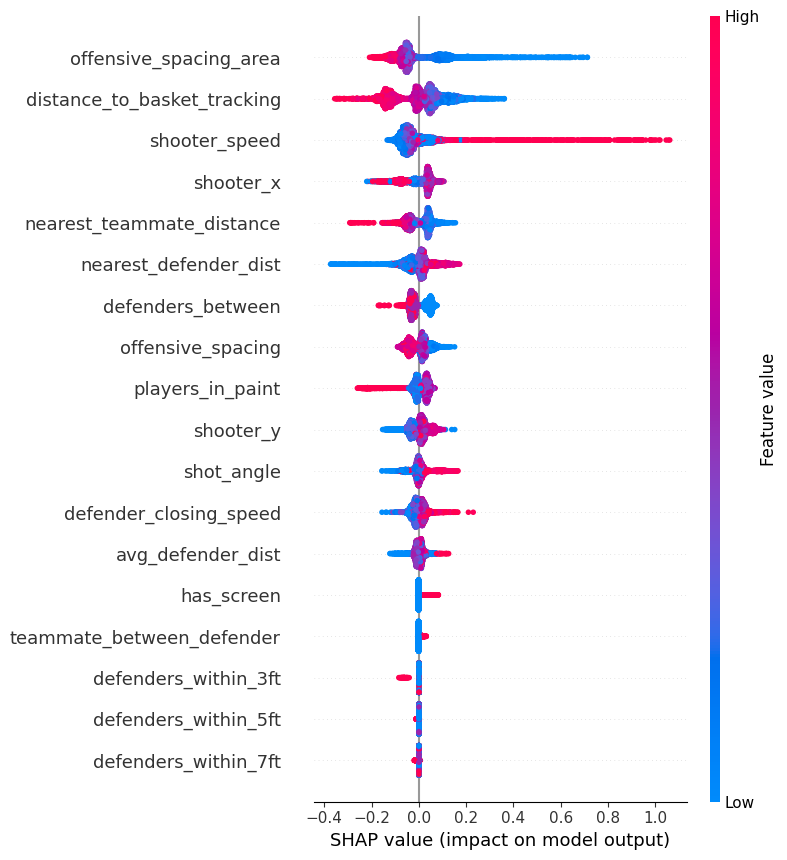

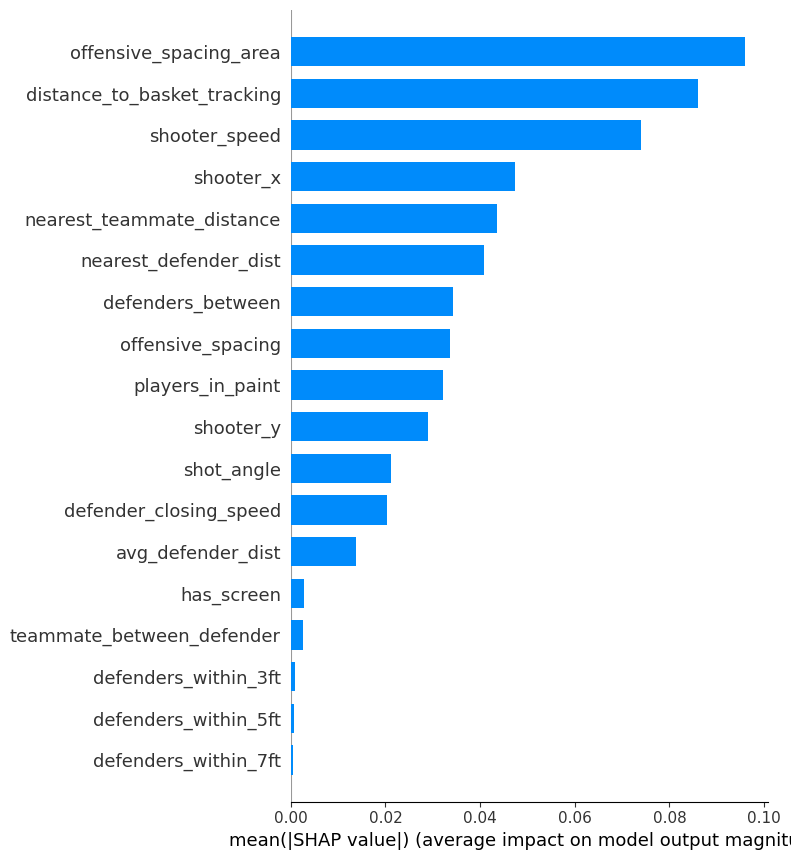

In [367]:
X_train_sel = pipeline.named_steps["feature_selection"].transform(X_train)
model = pipeline.named_steps["model"]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train_sel)

shap.summary_plot(shap_values, X_train_sel)
shap.summary_plot(shap_values, X_train_sel, plot_type="bar")

In [369]:
i = 531  # sample index

shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[i],
    X_train_sel.iloc[i]
)

In [166]:
X_eval = X_train_sel.copy()
X_eval["ACTION_TYPE"] = X_train["ACTION_TYPE"].values

df_shap = pd.DataFrame(shap_values, columns=X_train_sel.columns)
df_shap["ACTION_TYPE"] = X_eval["ACTION_TYPE"]
df_shap.groupby("ACTION_TYPE").mean().T

ACTION_TYPE,Alley Oop Dunk Shot,Alley Oop Layup shot,Cutting Dunk Shot,Cutting Finger Roll Layup Shot,Cutting Layup Shot,Driving Bank Hook Shot,Driving Bank shot,Driving Dunk Shot,Driving Finger Roll Layup Shot,Driving Floating Bank Jump Shot,Driving Floating Jump Shot,Driving Hook Shot,Driving Jump shot,Driving Layup Shot,Driving Reverse Dunk Shot,Driving Reverse Layup Shot,Dunk Shot,Fadeaway Bank shot,Fadeaway Jump Shot,Finger Roll Layup Shot,Floating Jump shot,Hook Bank Shot,Hook Shot,Jump Bank Shot,Jump Shot,Layup Shot,No Shot,Pullup Bank shot,Pullup Jump shot,Putback Dunk Shot,Putback Layup Shot,Reverse Dunk Shot,Reverse Layup Shot,Running Alley Oop Dunk Shot,Running Alley Oop Layup Shot,Running Dunk Shot,Running Finger Roll Layup Shot,Running Hook Shot,Running Jump Shot,Running Layup Shot,Running Pull-Up Jump Shot,Running Reverse Dunk Shot,Running Reverse Layup Shot,Step Back Bank Jump Shot,Step Back Jump shot,Tip Dunk Shot,Tip Layup Shot,Turnaround Bank Hook Shot,Turnaround Bank shot,Turnaround Fadeaway Bank Jump Shot,Turnaround Fadeaway shot,Turnaround Hook Shot,Turnaround Jump Shot
shooter_x,0.000765,-0.000202,0.001105,-0.001095,-0.000976,0.003596,0.001538,-0.000018,-0.004365,0.002571,0.000161,0.004176,-0.011617,-0.002661,-0.007612,-0.007300,-0.003187,0.003505,-0.000921,-4.007615e-03,0.000857,0.002074,0.002263,0.001073,-0.000490,-0.007711,-0.002877,-0.003245,0.002763,0.000066,-0.004962,-0.003449,-0.009800,0.010949,-0.002414,0.006923,0.002098,0.012912,-0.001062,-0.004770,0.004580,-0.023018,-0.004638,0.007883,0.002049,-0.008549,-0.008257,0.006115,0.003309,0.008205,0.001233,0.000064,-0.001108
shooter_y,0.004404,0.004590,0.004083,0.004050,0.004071,0.005899,0.000835,0.002759,0.002298,0.001670,0.002911,0.005076,0.003302,0.002197,-0.000181,0.001523,0.004200,0.000161,-0.000829,2.457684e-03,0.001851,0.004769,0.005438,0.001692,-0.002628,0.003367,0.002369,-0.000835,-0.000911,0.003933,0.004122,0.001905,0.003050,0.003147,0.002600,0.002797,0.002113,0.005850,0.000328,0.002346,0.001460,0.003365,0.002809,-0.000545,-0.001944,0.004257,0.004618,0.005025,0.002740,0.001310,0.000866,0.004746,0.001580
shot_angle,0.000406,0.000495,0.000754,0.001831,-0.000030,0.003361,0.000057,0.000483,-0.000022,0.000993,0.001036,0.002364,-0.009511,-0.000389,-0.007180,-0.003358,-0.001341,0.002194,-0.000901,7.341632e-04,0.000631,-0.000033,0.001787,0.000611,-0.000695,-0.001704,-0.004483,0.001668,0.001209,0.000352,-0.001983,-0.002936,-0.005855,0.005038,0.000457,0.001594,0.001100,0.003340,0.000162,0.000099,0.000219,-0.012113,-0.002120,-0.000649,0.000517,-0.000168,-0.002659,0.001281,0.001042,0.002560,-0.000941,0.000902,0.000498
distance_to_basket_tracking,0.092852,0.082644,0.090629,0.070792,0.100876,0.144123,0.043534,0.062964,0.057644,0.041338,0.056037,0.125676,0.127368,0.063829,0.148370,0.075264,0.087853,0.111681,0.035816,5.030423e-02,0.045444,0.126948,0.133638,0.060151,-0.068974,0.076770,0.064409,0.018196,-0.039815,0.084048,0.103906,0.027189,0.091251,-0.031891,-0.102153,0.029930,0.078211,0.000786,0.003634,0.055198,-0.062622,0.049646,0.099085,0.013665,-0.030458,0.067132,0.103685,0.139239,0.107527,0.097476,0.077996,0.123726,0.074349
nearest_defender_dist,-0.005724,-0.005331,-0.001771,-0.005807,-0.009091,-0.012084,-0.010004,-0.005930,-0.007782,-0.017957,-0.013849,-0.017016,-0.011257,-0.009453,-0.022733,-0.008554,-0.005350,-0.034401,-0.016233,-3.812629e-03,-0.011591,-0.023658,-0.014506,-0.016695,-0.001403,-0.010985,-0.013519,-0.012081,-0.008698,-0.009064,-0.018591,-0.005252,-0.010036,-0.010322,-0.042551,0.001238,-0.008317,-0.024759,-0.009431,-0.006617,-0.013195,-0.024686,-0.005154,0.006846,-0.010040,-0.016143,-0.014684,-0.027547,-0.022798,-0.012139,-0.015939,-0.014094,-0.016508
avg_defender_dist,0.008141,0.009303,0.008460,0.006936,0.005169,0.011136,0.001617,0.005460,0.002835,-0.001301,-0.001354,-0.004086,-0.014413,0.001769,0.011712,0.002030,0.006777,-0.000713,0.001907,5.563894e-03,0.002253,0.001853,0.001564,0.003377,0.002182,0.002650,0.006893,0.001822,0.004119,0.0032

# Random search

In [27]:
from sklearn.model_selection import RandomizedSearchCV

In [133]:
param_dist = {
    "model__n_estimators": [200, 300, 400, 500],
    "model__max_depth": [0, 3, 4, 5, 6, 7],
    "model__learning_rate": [0.0001, 0.001, 0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__gamma": [0, 0.001, 0.01, 0.1, 0.2],
    "model__min_child_weight": [0.1, 1, 3, 5]
}

search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=100,            
    scoring="roc_auc",
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

print("Best params:", search.best_params_)

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Best params: {'model__subsample': 0.7, 'model__n_estimators': 500, 'model__min_child_weight': 1, 'model__max_depth': 3, 'model__learning_rate': 0.01, 'model__gamma': 0}


In [134]:
# General metrics

y_pred_proba = best_model.predict_proba(X_test)
y_pred = best_model.predict(X_test)

print(roc_auc_score(y_test, y_pred_proba[:,1]))
display(pd.crosstab(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.5814021674418188


col_0,0,1
SHOT_MADE_FLAG,,
0,619,248
1,455,318


              precision    recall  f1-score   support

           0       0.58      0.71      0.64       867
           1       0.56      0.41      0.47       773

    accuracy                           0.57      1640
   macro avg       0.57      0.56      0.56      1640
weighted avg       0.57      0.57      0.56      1640



# Old model
- Test with the old dataset and model for comparison

In [30]:
data_train_old = pd.read_parquet(r"../../data/trajectory_tests/train_old_v2.parquet")
data_test_old = pd.read_parquet(r"../../data/trajectory_tests/test_old_v2.parquet")

X_train_old = data_train_old.drop('SHOT_MADE_FLAG', axis=1)
y_train_old = data_train_old['SHOT_MADE_FLAG']

X_test_old = data_test_old.drop('SHOT_MADE_FLAG', axis=1)
y_test_old = data_test_old['SHOT_MADE_FLAG']

In [31]:
feature_set_reduced = ['MAIN_ACTION_TYPE',
    'SHOT_DISTANCE',
    'PLAYER_NAME',
    'LOC_Y',
    'points',
    'year',
    'ABS_ANGLE',
    'TimeRemainingInPeriod',
    'PLAYER1_TEAM_ABBREVIATION',
    'TotalPlayedTime',
    'Opponent_team_abbreviation',
    'TimeRemainingInGame',
    'IS_HOME',
    'scoreMarginBeforeShot',
    'IsOvertime', 
    'is_playoffs', 
    ]

def select_features(df_):
    return df_[feature_set_reduced]

def add_additional_features(df_): 
    if not pd.api.types.is_datetime64_any_dtype(df_['GAME_DATE']):

        df_['GAME_DATE'] = pd.to_datetime(
            df_['GAME_DATE'].astype(str),
            format='%Y%m%d',
            errors='coerce'
        )
    df_['year'] = df_['GAME_DATE'].dt.year
    #df_['month'] = df_['GAME_DATE'].dt.month
    #df_['day'] = df_['GAME_DATE'].dt.weekday

    df_['Opponent_team_abbreviation'] = df_['HTM']
    df_.loc[df_['IS_HOME'] == 0, 'Opponent_team_abbreviation'] = df_.loc[df_['IS_HOME'] == 0, 'VTM']

    return df_

# Add free throw as main action type
def add_freethrow_actiontype(df_): 
    df_.loc[df_['ACTION_TYPE'] == 'Free Throw', 'MAIN_ACTION_TYPE'] = 'Free Throw'
    
    return df_

X_train_old = add_freethrow_actiontype(X_train_old)
X_test_old = add_freethrow_actiontype(X_test_old)

In [32]:
X_train_old.head()

,GAME_ID_x,GAME_EVENT_ID,SHOT_TYPE,SHOT_DISTANCE,SHOT_ZONE_RANGE,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,LOC_X,LOC_Y,ACTION_TYPE,HTM,VTM,GAME_DATE,TEAM_ID,PLAYER1_TEAM_ABBREVIATION,PLAYER_ID,scoreHome,scoreAway,shotResult,MINUTES_REMAINING,SECONDS_REMAINING,clock,PLAYER_NAME,PERIOD_x,PLAYER2_ID,PLAYER2_NAME,PLAYER2_TEAM_ABBREVIATION,PLAYER3_ID,PLAYER3_NAME,is_playoffs,PCTIMESTRING,IS_HOME,points,pointsHome,pointsAway,scoreHomeBeforeShot,scoreAwayBeforeShot,scoreMargin,scoreMarginBeforeShot,TimeRemainingInPeriod,TotalPlayedTime,TimeRemainingInGame,IsOvertime,OvertimeNumber,IsClutchTime,OPPONENT_INTERFERED,ANGLE,ANGLE_SECTOR,ABS_ANGLE,ANGLE_SIN,ANGLE_COS,MAIN_ACTION_TYPE,__index_level_0__,year,match_key
0,21500002.0,168.0,2PT Field Goal,2.0,Less Than 8 ft.,Restricted Area,Center(C),-22.0,13.0,Driving Layup Shot,CHI,CLE,2015-10-27,1.610613e+09,CLE,2544.0,30,22,Missed,9.0,48.0,PT09M48.00S,LeBron James,2.0,0.0,NaN,NaN,0.0,NaN,False,9:48,0,2,0,0,30.0,22.0,-8,-8.0,588,852,2028,0,0,0,False,-59.420773,1,59.420773,-0.266237,-0.963908,Layup,264377,2015,21500002_168_
1,21500002.0,16.0,2PT Field Goal,21.0,16-24 ft.,Mid-Range,Center(C),19.0,214.0,Jump Shot,CHI,CLE,2015-10-27,1.610613e+09,CLE,2544.0,2,6,Missed,9.0,47.0,PT09M47.00S,LeBron James,1.0,0.0,NaN,NaN,0.0,NaN,False,9:47,0,2,0,0,2.0,6.0,4,4.0,587,133,2747,0,0,0,False,5.073705,0,5.073705,-0.935433,0.353505,Jump,264369,2015,21500002_16_
2,21500002.0,180.0,2PT Field Goal,13.0,8-16 ft.,Mid-Range,Left Side(L),-114.0,72.0,Jump Shot,CHI,CLE,2015-10-27,1.610613e+09,CHI,2200.0,32,22,Missed,8.0,46.0,PT08M46.00S,Pau Gasol,2.0,0.0,NaN,NaN,0.0,NaN,False,8:46,1,2,0,0,32.0,22.0,10,10.0,526,914,1966,0,0,0,False,-57.724356,1,57.724356,-0.922955,0.384908,Jump,264378,2015,21500002_180_
3,21500002.0,182.0,3PT Field Goal,24.0,24+ ft.,Above the Break 3,Right Side Center(RC),115.0,218.0,Pullup Jump shot,CHI,CLE,2015-10-27,1.610613e+09,CLE,2544.0,32,22,Missed,8.0,36.0,PT08M36.00S,LeBron James,2.0,0.0,NaN,NaN,0.0,NaN,False,8:36,0,3,0,0,32.0,22.0,-10,-10.0,516,924,1956,0,0,0,False,27.812675,0,27.812675,0.445434,-0.895315,Jump,264379,2015,21500002_182_
4,21500002.0,184.0,2PT Field Goal,2.0,Less Than 8 ft.,Restricted Area,Center(C),-12.0,21.0,Driving Layup Shot,CHI,CLE,2015-10-27,1.610613e+09,CLE,2544.0,32,22,Missed,8.0,26.0,PT08M26.00S,LeBron James,2.0,0.0,NaN,NaN,202710.0,Jimmy Butler,False,8:26,0,2,0,0,32.0,22.0,-10,-10.0,506,934,1946,0,0,0,False,-29.744881,0,29.744881,0.994979,-0.100081,Layup,264380,2015,21500002_184_


In [33]:
cols_OneHot = ['PLAYER_NAME', 'is_playoffs', 'MAIN_ACTION_TYPE']
cols_targetEncode = ['PLAYER1_TEAM_ABBREVIATION', 'Opponent_team_abbreviation']

In [34]:
encoder_oh = OneHotEncoder(sparse_output=False, drop='first', handle_unknown="ignore")
encoder_target = TargetEncoder()
column_encoder = make_column_transformer(
    (encoder_oh, cols_OneHot),
    (encoder_target, cols_targetEncode),
    remainder='passthrough',
    verbose_feature_names_out=False
)
column_encoder.set_output(transform="pandas")

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoder', ...), ('targetencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` a

In [35]:
pipeline = Pipeline([
    ("feature_engineering",
     FunctionTransformer(add_additional_features)),
    ("feature_selection",
     FunctionTransformer(select_features)),
    ("encoding",
     column_encoder),
    ("model",
     XGBClassifier(
         n_estimators=500,
         max_depth=3,
         learning_rate=0.01,
         subsample=0.7,
         min_child_weight=1,
         gamma=0,
         random_state=42,
         n_jobs=-1,
         eval_metric="logloss"
     ))
])
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineering', ...), ('feature_selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...00223FF29EC00>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional ke

In [36]:
pipeline.fit(X_train_old, y_train_old)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineering', ...), ('feature_selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...00223FF29EC00>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional ke

In [37]:
# General metrics

y_pred_proba = pipeline.predict_proba(X_test_old)
y_pred = pipeline.predict(X_test_old)

print(roc_auc_score(y_test_old, y_pred_proba[:,1]))
display(pd.crosstab(y_test_old, y_pred))
print(classification_report(y_test_old, y_pred))

print("Brier score: ", brier_score_loss(y_test, y_pred_proba[:,1]))

0.6130185275540854


col_0,0,1
SHOT_MADE_FLAG,,
0.0,685,182
1.0,487,286


              precision    recall  f1-score   support

         0.0       0.58      0.79      0.67       867
         1.0       0.61      0.37      0.46       773

    accuracy                           0.59      1640
   macro avg       0.60      0.58      0.57      1640
weighted avg       0.60      0.59      0.57      1640

Brier score:  0.23514623939990997


In [10]:
# Build error Dataframe

error_df = X_test_old.copy()

error_df["y_true"] = y_test_old.values
error_df["y_pred"] = y_pred
error_df["y_pred_proba"] = y_pred_proba[:, 1]

# confidence
error_df["confidence"] = np.where(
    error_df["y_pred"] == 1,
    error_df["y_pred_proba"],
    1 - error_df["y_pred_proba"]
)

error_df["correct"] = (
    error_df["y_true"] == error_df["y_pred"]
)

# prediction error magnitude
error_df["error"] = abs(error_df["y_true"] - error_df["y_pred_proba"])

In [12]:
for action_type in error_df["MAIN_ACTION_TYPE"].value_counts().index[:15]:

    subset = error_df[
        error_df["MAIN_ACTION_TYPE"] == action_type
    ]

    accuracy = (
        subset["y_true"] == subset["y_pred"]
    ).mean()

    print("\n" + "="*60)
    print(f"{action_type}")
    print(f"n = {len(subset)}")
    print(f"accuracy = {accuracy:.3f}")
    print("="*60)

    cm = pd.crosstab(
        subset["y_true"],
        subset["y_pred"],
        rownames=["Actual"],
        colnames=["Predicted"]
    )

    display(cm)


Jump
n = 1122
accuracy = 0.586


Predicted,0,1
Actual,,
0.0,637,26
1.0,438,21



Layup
n = 373
accuracy = 0.574


Predicted,0,1
Actual,,
0.0,30,133
1.0,26,184



Dunk
n = 60
accuracy = 0.967


Predicted,1
Actual,
0.0,2
1.0,58



Other
n = 46
accuracy = 0.435


Predicted,0,1
Actual,,
0.0,15,8
1.0,18,5



Hook
n = 39
accuracy = 0.615


Predicted,0,1
Actual,,
0.0,9,7
1.0,8,15


# Combined
- Test combination of old and new dataset

In [38]:
data_train = pd.read_parquet(r"../../data/trajectory_tests/train_new_20_players_v2.parquet")
data_test = pd.read_parquet(r"../../data/trajectory_tests/test_new_20_players_v2.parquet")

X_train = data_train.drop('SHOT_MADE_FLAG', axis=1)
y_train = data_train['SHOT_MADE_FLAG']

X_test = data_test.drop('SHOT_MADE_FLAG', axis=1)
y_test = data_test['SHOT_MADE_FLAG']

## plots

In [200]:
X_train.head(2)

,Unnamed: 0,shooter_slot,shooter_x,shooter_y,shooter_team_id,shot_angle,distance_to_basket_tracking,nearest_defender_dist,avg_defender_dist,defenders_within_3ft,defenders_within_5ft,defenders_within_7ft,offensive_spacing_area,shooter_speed,player1_speed,player2_speed,player3_speed,player4_speed,player5_speed,player6_speed,player7_speed,player8_speed,player9_speed,player10_speed,ball_height,defender_closing_speed,ball_speed,ball_xy_speed,ACTION_TYPE,EVENTTIME,EVENT_TYPE,GAME_DATE,GAME_EVENT_ID,GAME_ID,GRID_TYPE,HTM,LOC_X,LOC_Y,MINUTES_REMAINING,PERIOD,PLAYER_ID,PLAYER_NAME,QUARTER,SECONDS_REMAINING,SHOT_ATTEMPTED_FLAG,SHOT_DISTANCE,SHOT_TIME,SHOT_TYPE,SHOT_ZONE_AREA,SHOT_ZONE_BASIC,SHOT_ZONE_RANGE,TEAM_ID,TEAM_NAME,VTM,tracking_game_clock,event_GAME_ID,event_EVENTNUM,event_EVENTMSGTYPE,event_EVENTMSGACTIONTYPE,event_PERIOD,event_WCTIMESTRING,event_PCTIMESTRING,event_HOMEDESCRIPTION,event_NEUTRALDESCRIPTION,event_VISITORDESCRIPTION,event_SCORE,event_SCOREMARGIN,event_PERSON1TYPE,event_PLAYER1_ID,event_PLAYER1_NAME,event_PLAYER1_TEAM_ID,event_PLAYER1_TEAM_CITY,event_PLAYER1_TEAM_NICKNAME,event_PLAYER1_TEAM_ABBREVIATION,event_PERSON2TYPE,event_PLAYER2_ID,event_PLAYER2_NAME,event_PLAYER2_TEAM_ID,event_PLAYER2_TEAM_CITY,event_PLAYER2_TEAM_NICKNAME,event_PLAYER2_TEAM_ABBREVIATION,event_PERSON3TYPE,event_PLAYER3_ID,event_PLAYER3_NAME,event_PLAYER3_TEAM_ID,event_PLAYER3_TEAM_CITY,event_PLAYER3_TEAM_NICKNAME,event_PLAYER3_TEAM_ABBREVIATION,ball_x,ball_y,ball_z,player1_team_id,player1_id,player1_x,player1_y,player2_team_id,player2_id,player2_x,player2_y,player3_team_id,player3_id,player3_x,player3_y,player4_team_id,player4_id,player4_x,player4_y,player5_team_id,player5_id,player5_x,player5_y,player6_team_id,player6_id,player6_x,player6_y,player7_team_id,player7_id,player7_x,player7_y,player8_team_id,player8_id,player8_x,player8_y,player9_team_id,player9_id,player9_x,player9_y,player10_team_id,player10_id,player10_x,player10_y,nearest_teammate_distance,defenders_between,has_screen,offensive_spacing,teammate_between_defender,players_in_paint,match_key
0,19796,7.0,91.84720,21.73185,1.610613e+09,128.474179,4.174476,3.739720,17.027419,0.0,1.0,2.0,192.790840,7.601442,4.760868,4.324057,5.299312,11.645432,2.194626,0.155994,7.601442,4.621345,1.110809,4.688567,10.84648,4.666324,3.739744,2.564110,Driving Layup Shot,588,Missed Shot,20151027,168,21500002,Shot Chart Detail,CHI,-13.1431,3.2090,9,2,2544,LeBron James,2.0,48,1,2,589.78,2PT Field Goal,Center(C),Restricted Area,Less Than 8 ft.,1610612739,Cleveland Cavaliers,CLE,589.78,21500002,168,2,42,2,8:36 PM,9:48,NaN,NaN,MISS James 3' Driving Layup,NaN,NaN,5.0,2544,LeBron James,1.610613e+09,Cleveland,Cavaliers,CLE,0,0,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,88.92910,23.68569,10.84648,1.610613e+09,2200.0,72.16338,23.34857,1.610613e+09,201959.0,81.80425,25.79869,1.610613e+09,202734.0,85.86070,24.99180,1.610613e+09,201565.0,48.18202,27.11361,1.610613e+09,202710.0,88.46644,20.13311,1.610613e+09,2590.0,89.48968,48.06415,1.610613e+09,2544.0,91.84720,21.73185,1.610613e+09,2747.0,89.72315,1.38897,1.610613e+09,201567.0,89.74136,19.23182,1.610613e+09,202389.0,83.58420,22.14018,3.268748,0,1,20.682279,1,6,21500002_168_2544
1,19790,7.0,68.02864,29.74118,1.610613e+09,-12.593942,21.744537,6.422425,14.775858,0.0,0.0,1.0,568.309914,3.007818,1.344771,0.366893,9.677547,5.732129,1.482779,4.772839,3.007818,1.966085,2.212518,1.082775,6.88120,-3.509767,14.670812,12.546087,Jump Shot,587,Missed Shot,20151027,16,21500002,Shot Chart Detail,CHI,39.8725,208.6802,9,1,2544,LeBron James,1.0,47,1,21,590.16,2PT Field Goal,Center(C),Mid-Range,16-24 ft.,1610612739,Cleveland Cavaliers,CLE,590.16,21500002,16,2,1,1,8:05 PM,9:47,NaN,NaN,MISS James 21' Jump Shot,NaN,NaN,5.0,2544,LeBron James,1.610613e+09,Cleveland,Cavaliers,CLE,0,0,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,68.38198,28.98725,6.88120,1.610613e+09,2200.0,80.33227,32.23995,1.610613e+09,201565.0,86.38138,37.70774,1.610613e+09,202710.0,74.43205,29.24734,1.610613e+09,203503.0,7

In [204]:
X_train2 = X_train.copy()
X_train2['target'] = y_train

<Axes: ylabel='defenders_between'>

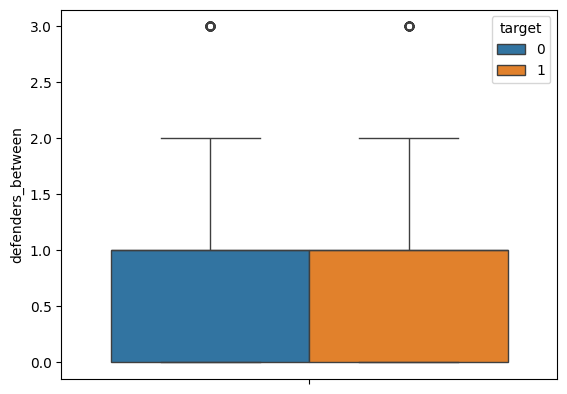

In [210]:
sns.boxplot(X_train2, y='defenders_between', hue='target')

<Axes: >

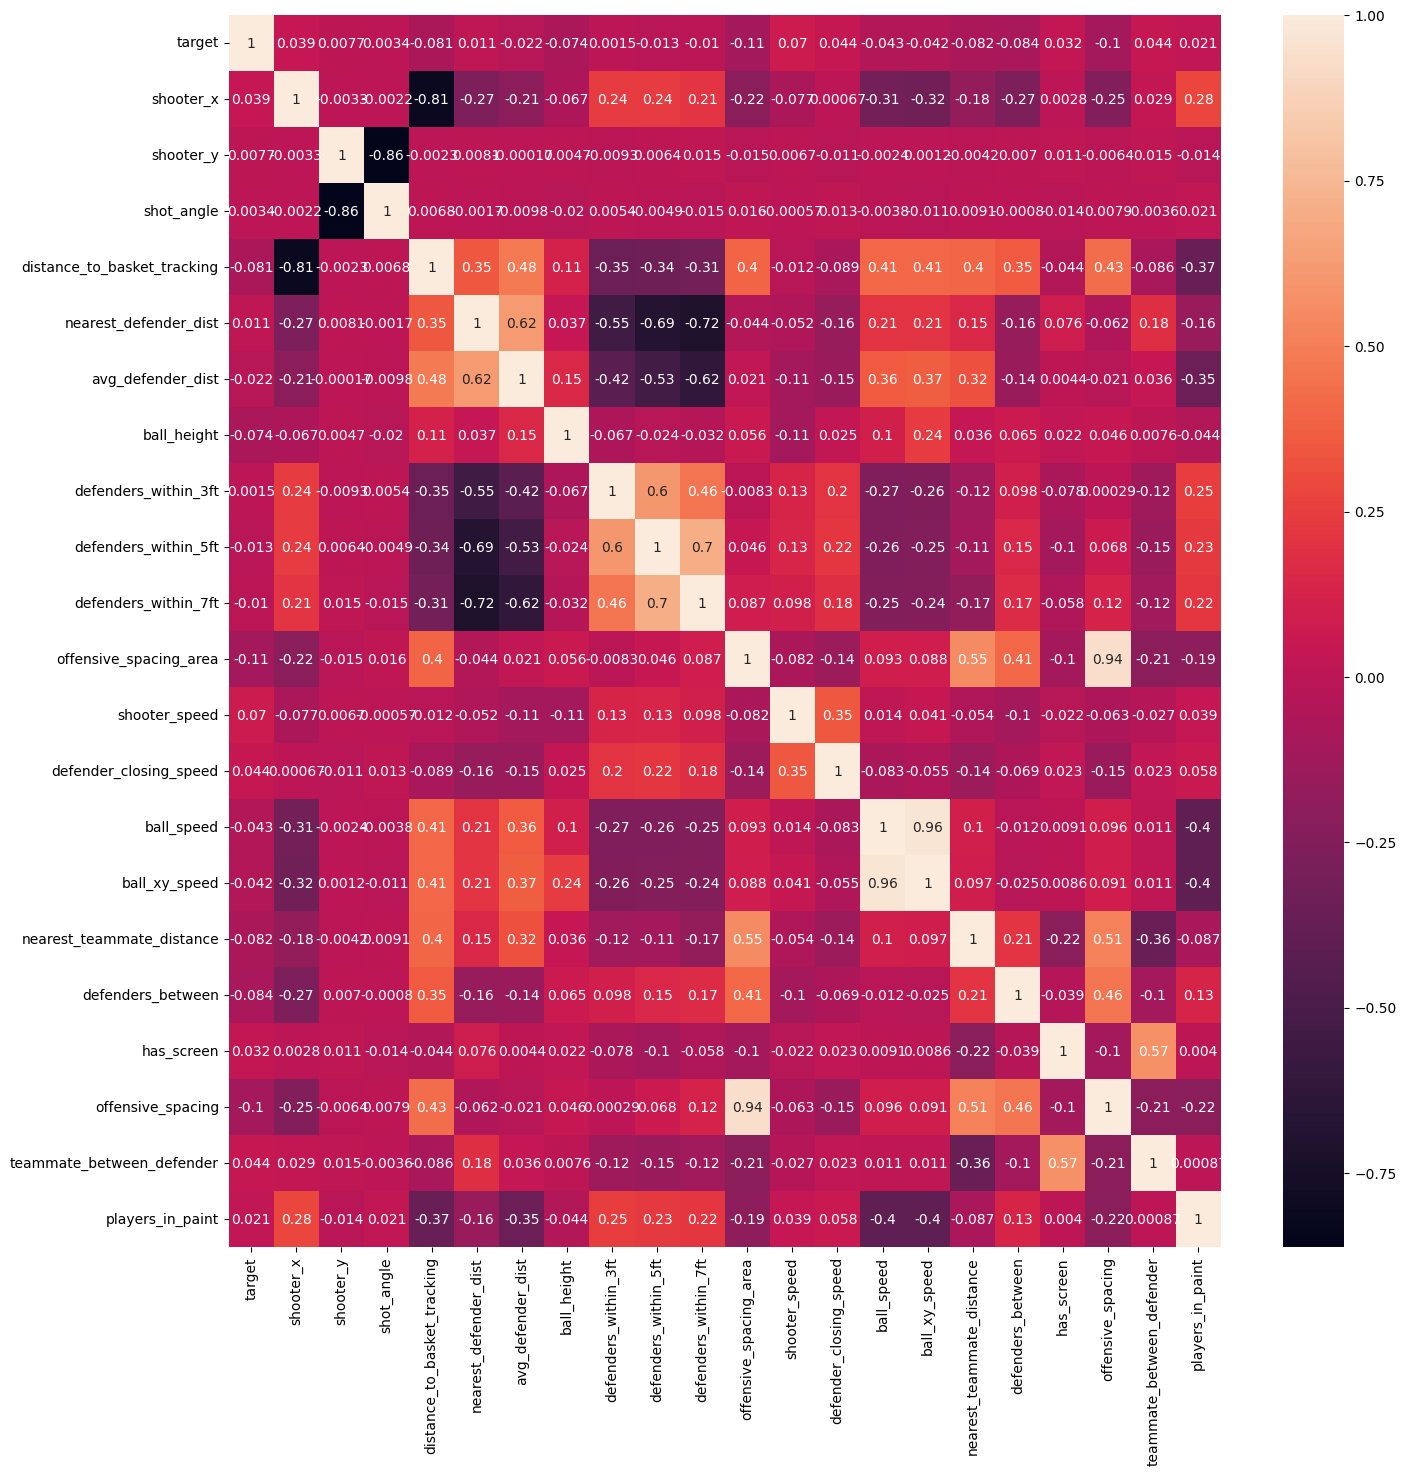

In [214]:
cols = ['target', 'shooter_x', 'shooter_y', 'shot_angle', 'distance_to_basket_tracking', 'nearest_defender_dist',
    'avg_defender_dist', 'ball_height', 'defenders_within_3ft', 'defenders_within_5ft', 'defenders_within_7ft',
   'offensive_spacing_area', 'shooter_speed', 'defender_closing_speed', 'ball_speed', 'ball_xy_speed',
    'nearest_teammate_distance', 'defenders_between', 'has_screen', 'offensive_spacing', 'teammate_between_defender', 'players_in_paint']

plt.figure(figsize=(16,16))
sns.heatmap(X_train2[cols].corr(), annot=True)

## combine datasets and train

In [39]:
data_train_combined = data_train.merge(data_train_old, on='match_key', how='left', suffixes=(None, "_y")) 
data_test_combined = data_test.merge(data_test_old, on='match_key', how='left', suffixes=(None, "_y")) 

X_train_combined = data_train_combined.drop('SHOT_MADE_FLAG', axis=1)
y_train_combined = data_train_combined['SHOT_MADE_FLAG']

X_test_combined = data_test_combined.drop('SHOT_MADE_FLAG', axis=1)
y_test_combined = data_test_combined['SHOT_MADE_FLAG']

In [44]:
feature_set_reduced = ['MAIN_ACTION_TYPE',
    'PLAYER_NAME',
    #'points',
    'TimeRemainingInPeriod',
    #'PLAYER1_TEAM_ABBREVIATION',
    'TotalPlayedTime',
    #'Opponent_team_abbreviation',
    'TimeRemainingInGame',
    'IS_HOME'
    ]

feature_set_reduced.extend(['shooter_x', 'shooter_y', 'shot_angle', 'distance_to_basket_tracking', 'nearest_defender_dist',
    'avg_defender_dist', 'defenders_within_3ft', 'defenders_within_5ft', 'defenders_within_7ft',
    'shooter_speed', 'defender_closing_speed',
    'nearest_teammate_distance', 'defenders_between', 'has_screen', 'offensive_spacing', 'teammate_between_defender', 'players_in_paint'])

cols_OneHot = ['PLAYER_NAME', 'MAIN_ACTION_TYPE']
#cols_OneHot = ['PLAYER_NAME']
#cols_targetEncode = ['PLAYER1_TEAM_ABBREVIATION', 'Opponent_team_abbreviation']
cols_targetEncode = []

In [45]:
encoder_oh = OneHotEncoder(sparse_output=False, drop='first', handle_unknown="ignore")
encoder_target = TargetEncoder()
column_encoder = make_column_transformer(
    (encoder_oh, cols_OneHot),
    (encoder_target, cols_targetEncode),
    remainder='passthrough',
    verbose_feature_names_out=False
)
column_encoder.set_output(transform="pandas")

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoder', ...), ('targetencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` a

In [46]:
pipeline = Pipeline([
    ("feature_engineering",
     FunctionTransformer(add_additional_features)),
    ("feature_selection",
     FunctionTransformer(select_features)),
    ("encoding",
     column_encoder),
    ("model",
     XGBClassifier(
         n_estimators=500,
         max_depth=3,
         learning_rate=0.01,
         subsample=0.7,
         min_child_weight=1,
         gamma=0,
         random_state=42,
         n_jobs=-1,
         eval_metric="logloss"
     ))
])

# {'model__subsample': 0.7, 'model__n_estimators': 500, 'model__min_child_weight': 1, 'model__max_depth': 3, 'model__learning_rate': 0.01, 'model__gamma': 0}
pipeline.fit(X_train_combined, y_train_combined)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineering', ...), ('feature_selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...00223FF29EC00>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional ke

In [48]:
# General metrics

y_pred_proba = pipeline.predict_proba(X_test_combined)
y_pred = pipeline.predict(X_test_combined)

print(roc_auc_score(y_test_combined, y_pred_proba[:,1]))
display(pd.crosstab(y_test_combined, y_pred))
print(classification_report(y_test_old, y_pred))

print("Brier score: ", brier_score_loss(y_test, y_pred_proba[:,1]))

0.6135556878561484


col_0,0,1
SHOT_MADE_FLAG,,
0,666,201
1,462,311


              precision    recall  f1-score   support

         0.0       0.59      0.77      0.67       867
         1.0       0.61      0.40      0.48       773

    accuracy                           0.60      1640
   macro avg       0.60      0.59      0.58      1640
weighted avg       0.60      0.60      0.58      1640

Brier score:  0.2378602921962738


In [49]:
# Build error Dataframe

error_df = X_test_combined.copy()

error_df["y_true"] = y_test_combined.values
error_df["y_pred"] = y_pred
error_df["y_pred_proba"] = y_pred_proba[:, 1]

# confidence
error_df["confidence"] = np.where(
    error_df["y_pred"] == 1,
    error_df["y_pred_proba"],
    1 - error_df["y_pred_proba"]
)

error_df["correct"] = (
    error_df["y_true"] == error_df["y_pred"]
)

# prediction error magnitude
error_df["error"] = abs(error_df["y_true"] - error_df["y_pred_proba"])

In [50]:
for action_type in error_df["MAIN_ACTION_TYPE"].value_counts().index[:15]:

    subset = error_df[
        error_df["MAIN_ACTION_TYPE"] == action_type
    ]

    accuracy = (
        subset["y_true"] == subset["y_pred"]
    ).mean()

    print("\n" + "="*60)
    print(f"{action_type}")
    print(f"n = {len(subset)}")
    print(f"accuracy = {accuracy:.3f}")
    print("="*60)

    cm = pd.crosstab(
        subset["y_true"],
        subset["y_pred"],
        rownames=["Actual"],
        colnames=["Predicted"]
    )

    display(cm)


Jump
n = 1122
accuracy = 0.591


Predicted,0,1
Actual,,
0,654,9
1,450,9



Layup
n = 373
accuracy = 0.566


Predicted,0,1
Actual,,
0,8,155
1,7,203



Dunk
n = 60
accuracy = 0.967


Predicted,1
Actual,
0,2
1,58



Other
n = 46
accuracy = 0.500


Predicted,0,1
Actual,,
0,3,20
1,3,20



Hook
n = 39
accuracy = 0.564


Predicted,0,1
Actual,,
0,1,15
1,2,21


# SHAP

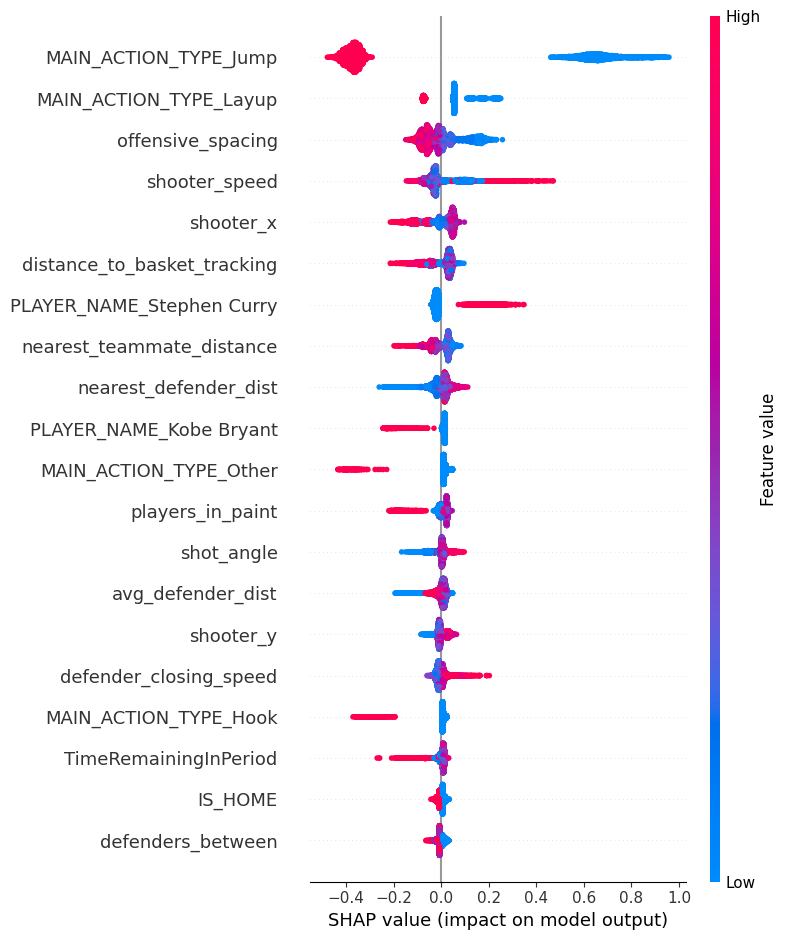

In [57]:
X_train_sel = pipeline.named_steps["feature_selection"].transform(X_train_combined)
X_train_sel = pipeline.named_steps["encoding"].transform(X_train_sel)
model = pipeline.named_steps["model"]

y_pred_train = model.predict(X_train_sel)
y_proba_train = model.predict_proba(X_train_sel)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train_sel)

shap.summary_plot(shap_values, X_train_sel)
#shap.summary_plot(shap_values, X_train_sel, plot_type="bar")

In [59]:
#i = 531  # sample index
i=np.random.randint(len(X_train.index))

print(f"Predicted: {y_pred_train[i]}, Proba: {y_proba_train[i,1]}, actual: {y_train.iloc[i]}")

shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[i],
    X_train_sel.iloc[i]
)

Predicted: 0, Proba: 0.3575456142425537, actual: 0


In [53]:
X_eval = X_train_sel.copy()
X_eval["MAIN_ACTION_TYPE"] = X_train_combined["MAIN_ACTION_TYPE"].values

df_shap = pd.DataFrame(shap_values, columns=X_train_sel.columns)
df_shap["MAIN_ACTION_TYPE"] = X_eval["MAIN_ACTION_TYPE"]
df_shap.groupby("MAIN_ACTION_TYPE").mean().T

MAIN_ACTION_TYPE,Dunk,Hook,Jump,Layup,Other
PLAYER_NAME_Chris Paul,-0.000128,-0.000154,0.000033,-0.000041,0.000018
PLAYER_NAME_Dirk Nowitzki,-0.000137,-0.000099,0.000029,-0.000110,0.000405
PLAYER_NAME_Draymond Green,-0.000050,0.000209,0.000051,-0.000117,0.000132
PLAYER_NAME_Dwyane Wade,0.000200,-0.000229,-0.000034,-0.000069,-0.000634
PLAYER_NAME_Giannis Antetokounmpo,-0.004984,-0.003873,0.000269,-0.001652,0.000993
PLAYER_NAME_James Harden,0.001727,0.001919,-0.000167,-0.000234,0.001616
PLAYER_NAME_Kawhi Leonard,0.000274,0.000146,0.000038,-0.000291,-0.000090
PLAYER_NAME_Kevin Durant,0.003130,-0.003058,0.000524,-0.002263,-0.000337
PLAYER_NAME_Kevin Garnett,-0.000542,0.000100,0.000107,-0.000453,0.000137
PLAYER_NAME_Kobe Bryant,0.009246,0.006768,-0.003258,0.007364,-0.006695


# Plot differetn game situations

In [54]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle, Arc
from matplotlib.lines import Line2D
import pandas as pd


def plot_shot_frame(
    df,
    y_true,
    y_pred,
    idx,
    annotate_players=True,
    show_ball=True,
    figsize=(8, 8)
):
    """
    Plot one shot frame from merged_df.

    Parameters
    ----------
    df : pd.DataFrame
        merged dataframe

    idx : int
        row index

    annotate_players : bool
        show player ids

    show_ball : bool
        show ball position

    """

    row = df.iloc[idx]
    true_val = y_true[idx]
    pred_val = y_pred[idx]

    # Figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Court
    lw = 1
    color = "black"

    hoop = Circle(
        (25, 89.25),
        radius=.85,
        linewidth=lw,
        color=color,
        fill=False
    )

    outer_box = Rectangle(
        (17, 75),
        16,
        19,
        linewidth=lw,
        color=color,
        fill=False
    )

    inner_box = Rectangle(
        (19, 75),
        12,
        19,
        linewidth=lw,
        color=color,
        fill=False
    )

    top_free_throw = Arc(
        (25, 75),
        12,
        12,
        theta1=180,
        theta2=0,
        linewidth=lw,
        color=color
    )

    bottom_free_throw = Arc(
        (25, 75),
        12,
        12,
        theta1=0,
        theta2=180,
        linewidth=lw,
        color=color,
        linestyle="dashed"
    )

    corner_three_a = Rectangle(
        (3, 80),
        0,
        14,
        linewidth=lw,
        color=color
    )

    corner_three_b = Rectangle(
        (47, 80),
        0,
        14,
        linewidth=lw,
        color=color
    )

    three_arc = Arc(
        (25, 89.25),
        47.5,
        47.5,
        theta1=202,
        theta2=337.5,
        linewidth=lw,
        color=color
    )

    court_elements = [
        hoop,
        outer_box,
        inner_box,
        top_free_throw,
        bottom_free_throw,
        corner_three_a,
        corner_three_b,
        three_arc
    ]

    for element in court_elements:
        ax.add_patch(element)

    # Plot players
    shooter_id = row.get("PLAYER_ID", None)
    shooter_team = row.get("shooter_team_id", None)

    for i in range(1, 11):

        x_col = f"player{i}_y"
        y_col = f"player{i}_x"
        id_col = f"player{i}_id"
        team_col = f"player{i}_team_id"

        if x_col not in row:
            continue

        x = row[x_col]
        y = row[y_col]
        pid = row[id_col]
        tid = row[team_col]

        if pd.isna(x) or pd.isna(y):
            continue

        # Colors
        if pid == shooter_id:
            marker = "o"
            size = 180
            color = "green"

        elif tid == shooter_team:
            marker = "o"
            size = 120
            color = "blue"

        else:
            marker = "o"
            size = 120
            color = "red"

        ax.scatter(
            x,
            y,
            s=size,
            c=color,
            edgecolors="black"
        )

        # Player labels
        if annotate_players:

            ax.text(
                x,
                y,
                str(int(pid)),
                fontsize=8,
                ha="center",
                va="center",
                color="white",
                weight="bold"
            )

    # Ball
    if show_ball:

        bx = row.get("ball_y", None)
        by = row.get("ball_x", None)

        if pd.notna(bx) and pd.notna(by):

            ax.scatter(
                bx,
                by,
                s=60,
                c="orange",
                edgecolors="black",
                zorder=10
            )

    # Legend
    legend_elements = [

        Line2D(
            [0],
            [0],
            marker='o',
            color='w',
            label='Shooter',
            markerfacecolor='green',
            markeredgecolor='black',
            markersize=12
        ),

        Line2D(
            [0],
            [0],
            marker='o',
            color='w',
            label='Teammate',
            markerfacecolor='blue',
            markeredgecolor='black',
            markersize=10
        ),

        Line2D(
            [0],
            [0],
            marker='o',
            color='w',
            label='Defender',
            markerfacecolor='red',
            markeredgecolor='black',
            markersize=10
        ),

        Line2D(
            [0],
            [0],
            marker='o',
            color='w',
            label='Ball',
            markerfacecolor='orange',
            markeredgecolor='black',
            markersize=8
        )
    ]

    ax.legend(
        handles=legend_elements,
        loc="lower left",
        fontsize=9
    )

    # Meta info
    title = (
        f"{row.get('PLAYER_NAME', '')} | "
        f"{row.get('ACTION_TYPE', '')} | "
        f"Made: {true_val} | "
        f"Pred: {pred_val}"
        
    )
    plt.title(title)

    # Layout
    plt.xlim(0, 50)
    plt.ylim(47, 94)

    ax.set_aspect("equal", adjustable="box")

    plt.tight_layout()
    plt.show()

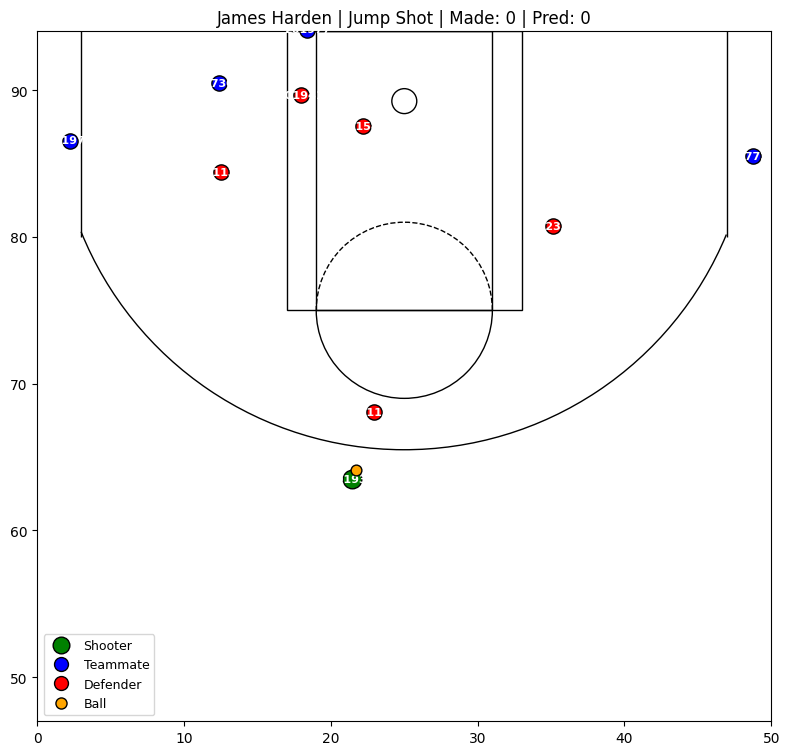

In [60]:
#idx=np.random.randint(len(X_train.index))
idx = i

plot_shot_frame(X_train, y_train, y_pred_train, idx=idx)